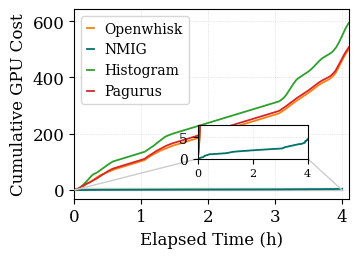

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib as mpl


mpl.rcParams['font.family'] = 'DejaVu Serif'
#similar dataset
# filename = "graphs_images/gpu_cost_similar.jpg"
# experiments = [
#     {"id": "exp_20250625_162425", "name": "Openwhisk"},
#     {"id": "exp_20250625_113106", "name": "Proposed"},
#     {"id": "exp_20250625_211541", "name": "Histogram"},
#     {"id": "exp_20250626_050332", "name": "Pagurus"},
# ]
first_invocation_time = 0

# normal dataset
filename = "graphs_images/gpu_cost_normal_proposed.jpg"
experiments = [
    {"id": "exp_20250626_205804", "name": "Openwhisk"},
    {"id": "exp_20250627_042542", "name": "NMIG"},
    {"id": "exp_20250626_155721", "name": "Histogram"},
    {"id": "exp_20250626_113035", "name": "Pagurus"},
]

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

style_map = {
    "NMIG": ("-", ""),
    "Openwhisk": ("--", ""),
    "Histogram": (":", ""),
    "Pagurus": ("-.", "")
}

MB_TO_GB = 1024.0 

first_invocation_time = 0
# filename = "graphs_images/gpu_cost_bursty.jpg"
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
# first_invocation_time = 33.14

COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_time * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')


    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    # cost_per_second['overall_cost'].fillna(0, inplace=True)
    cost_per_second['overall_cost'] = cost_per_second['overall_cost'].fillna(0)


    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding to full 4 hours
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# ---------- Plotting with Inset Zoom ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()

# for name, df in aligned_results.items():
#     ax.plot(
#         df['relative_hours'],
#         df['cumulative_cost'],
#         label=name,
#         linewidth=1.3,
#         linestyle='-',
#         marker=''
#     )

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),  # unified colors
        marker=''
    )


# Apply scientific notation to x-axis
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  # tick every 0.5 hours


plt.xlabel('Elapsed Time (h)', fontsize=12)
plt.ylabel('Cumulative GPU Cost', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=10,handlelength=0.5)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(0, 1200)
plt.xlim(0, 4.1)
plt.tight_layout(pad=0.4)

# Create inset zoom plot
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left', borderpad=1.2)
axins = inset_axes(ax, width="80%", height="30%", 
                   bbox_to_anchor=(0.4, 0.001, 0.5, 0.6), 
                   bbox_transform=ax.transAxes, 
                   loc='center')

# for name, df in aligned_results.items():
#     axins.plot(df['relative_hours'], df['cumulative_cost'],
#                 label=name, linewidth=1.3, linestyle='-', marker='')
for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker=''
    )

# Zoom-in region for Proposed (lower range)
axins.set_xlim(0, 4)
axins.set_ylim(0, 8)  # adjust based on your actual Proposed cost
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.xticks(fontsize=8)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(-1,1))


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

# plt.savefig(filename, dpi=300)  # If using PIL backend

plt.show()


In [9]:
result_all = {key: df["cumulative_cost"].max() for key, df in aligned_results.items()}
result_all

{'Openwhisk': 521.675879999975,
 'NMIG': 4.586610000000007,
 'Histogram': 612.0103699999755,
 'Pagurus': 529.0651299999691}

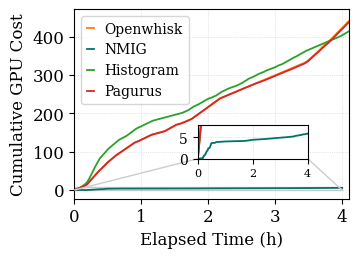

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib as mpl


mpl.rcParams['font.family'] = 'DejaVu Serif'
#similar dataset
filename = "graphs_images/gpu_cost_similar.jpg"
experiments = [
    {"id": "exp_20250625_162425", "name": "Openwhisk"},
    {"id": "exp_20250625_113106", "name": "NMIG"},
    {"id": "exp_20250625_211541", "name": "Histogram"},
    {"id": "exp_20250626_050332", "name": "Pagurus"},
]
first_invocation_time = 0



color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

style_map = {
    "NMIG": ("-", ""),
    "Openwhisk": ("--", ""),
    "Histogram": (":", ""),
    "Pagurus": ("-.", "")
}

first_invocation_time = 0
# filename = "graphs_images/gpu_cost_bursty.jpg"
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
# first_invocation_time = 33.14

COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_time * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')


    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    # cost_per_second['overall_cost'].fillna(0, inplace=True)
    cost_per_second['overall_cost'] = cost_per_second['overall_cost'].fillna(0)


    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding to full 4 hours
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# ---------- Plotting with Inset Zoom ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()

# for name, df in aligned_results.items():
#     ax.plot(
#         df['relative_hours'],
#         df['cumulative_cost'],
#         label=name,
#         linewidth=1.3,
#         linestyle='-',
#         marker=''
#     )

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),  # unified colors
        marker=''
    )


# Apply scientific notation to x-axis
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  # tick every 0.5 hours


plt.xlabel('Elapsed Time (h)', fontsize=12)
plt.ylabel('Cumulative GPU Cost', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=10,handlelength=0.5)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(0, 1200)
plt.xlim(0, 4.1)
plt.tight_layout(pad=0.4)

# Create inset zoom plot
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left', borderpad=1.2)
axins = inset_axes(ax, width="80%", height="30%", 
                   bbox_to_anchor=(0.4, 0.001, 0.5, 0.6), 
                   bbox_transform=ax.transAxes, 
                   loc='center')

# for name, df in aligned_results.items():
#     axins.plot(df['relative_hours'], df['cumulative_cost'],
#                 label=name, linewidth=1.3, linestyle='-', marker='')
for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker=''
    )

# Zoom-in region for Proposed (lower range)
axins.set_xlim(0, 4)
axins.set_ylim(0, 8)  # adjust based on your actual Proposed cost
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.xticks(fontsize=8)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(-1,1))


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

plt.savefig(filename, dpi=300)  # If using PIL backend

plt.show()


In [11]:
result_all = {key: df["cumulative_cost"].max() for key, df in aligned_results.items()}
result_all

{'Openwhisk': 448.9181600000587,
 'NMIG': 5.90368000000003,
 'Histogram': 416.788890000029,
 'Pagurus': 445.8330700000476}

In [5]:
aligned_results['Openwhisk']['cumulative_cost'].max(),aligned_results['Proposed']['cumulative_cost'].max(),aligned_results['Proposed']['cumulative_cost'].max()

521.675879999975

In [1]:
aligned_results

NameError: name 'aligned_results' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib as mpl


mpl.rcParams['font.family'] = 'DejaVu Serif'
#similar dataset
# filename = "graphs_images/gpu_cost_similar.jpg"
# experiments = [
#     {"id": "exp_20250625_162425", "name": "Openwhisk"},
#     {"id": "exp_20250625_113106", "name": "Proposed"},
#     {"id": "exp_20250625_211541", "name": "Histogram"},
#     {"id": "exp_20250626_050332", "name": "Pagurus"},
# ]
first_invocation_time = 0

# normal dataset
filename = "graphs_images/gpu_cost_normal_proposed.jpg"
experiments = [
    {"id": "exp_20250626_205804", "name": "Openwhisk"},
    {"id": "exp_20250627_042542", "name": "NMIG"},
    {"id": "exp_20250626_155721", "name": "Histogram"},
    {"id": "exp_20250626_113035", "name": "Pagurus"},
]

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728"
}

style_map = {
    "NMIG": ("-", ""),
    "Openwhisk": ("--", ""),
    "Histogram": (":", ""),
    "Pagurus": ("-.", "")
}

first_invocation_time = 0
# filename = "graphs_images/gpu_cost_bursty.jpg"
# experiments = [
#     {"id": "exp_20250625_014444", "name": "Openwhisk"},
#     {"id": "exp_20250625_071954", "name": "Proposed"},
#     {"id": "exp_20250624_210136", "name": "Histogram"},
#     {"id": "exp_20250624_165438", "name": "Pagurus"},
# ]
# first_invocation_time = 33.14

COST_PER_MB_PER_SECOND = 0.00001
aligned_results = {}

for exp in experiments:
    fn_path = f"../results/{exp['id']}/results_updated.csv"
    fn = pd.read_csv(fn_path)
    gpu_path = f"../results/{exp['id']}/gpu_usage.csv"
    df = pd.read_csv(gpu_path)

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_time * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')


    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['cost_rate'] = df_avg['Avg_GPU_Memory_MB'] * COST_PER_MB_PER_SECOND

    cost_per_second = (
        df_avg.groupby('second_level_datetime')['cost_rate']
              .sum()
              .reset_index(name='overall_cost')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    cost_per_second['relative_seconds'] = (
        (cost_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    cost_per_second = cost_per_second[cost_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = cost_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    cost_per_second = full_sec.merge(cost_per_second, on='relative_seconds', how='left')
    # cost_per_second['overall_cost'].fillna(0, inplace=True)
    cost_per_second['overall_cost'] = cost_per_second['overall_cost'].fillna(0)


    cost_per_second['cumulative_cost'] = cost_per_second['overall_cost'].cumsum()
    cost_per_second['relative_hours'] = cost_per_second['relative_seconds'] / 3600

    # Padding to full 4 hours
    t_target_seconds = 4 * 3600
    if cost_per_second['relative_seconds'].max() < t_target_seconds:
        last_cost = cost_per_second['cumulative_cost'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target_seconds],
            'overall_cost': [0],
            'cumulative_cost': [last_cost],
            'relative_hours': [t_target_seconds / 3600]
        })
        cost_per_second = pd.concat([cost_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = cost_per_second

# ---------- Plotting with Inset Zoom ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()


for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),  # unified colors
        marker=''
    )


# Apply scientific notation to x-axis
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  # tick every 0.5 hours


plt.xlabel('Elapsed Time (h)', fontsize=12)
plt.ylabel('Cumulative GPU Cost', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=10,handlelength=0.5)
plt.grid(linestyle=':', linewidth=0.5, alpha=0.6)
# plt.ylim(0, 1200)
plt.xlim(0, 4.1)
plt.tight_layout(pad=0.4)

# Create inset zoom plot
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left', borderpad=1.2)
axins = inset_axes(ax, width="80%", height="30%", 
                   bbox_to_anchor=(0.4, 0.001, 0.5, 0.6), 
                   bbox_transform=ax.transAxes, 
                   loc='center')

# for name, df in aligned_results.items():
#     axins.plot(df['relative_hours'], df['cumulative_cost'],
#                 label=name, linewidth=1.3, linestyle='-', marker='')
for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_cost'],
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker=''
    )

# Zoom-in region for Proposed (lower range)
axins.set_xlim(0, 4)
axins.set_ylim(0, 8)  # adjust based on your actual Proposed cost
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
plt.xticks(fontsize=8)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(-1,1))


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

# plt.savefig(filename, dpi=300)  # If using PIL backend

plt.show()


In [4]:
import pandas as pd
import numpy as np

# ---- point this at whichever dataset you're processing ----
#normal
# experiments = [
#     {"id": "exp_20250626_205804", "name": "Openwhisk"},
#     {"id": "exp_20250627_042542", "name": "NMIG"},
#     {"id": "exp_20250626_155721", "name": "Histogram"},
#     {"id": "exp_20250626_113035", "name": "Pagurus"},
# ]
#similar
experiments = [
    {"id": "exp_20250625_162425", "name": "Openwhisk"},
    {"id": "exp_20250625_113106", "name": "NMIG"},
    {"id": "exp_20250625_211541", "name": "Histogram"},
    {"id": "exp_20250626_050332", "name": "Pagurus"},
]


first_invocation_time = 0
COST_PER_MB_PER_SECOND = 0.00001
T_TARGET = 4 * 3600

summary = {}

for exp in experiments:
    fn = pd.read_csv(f"../results/{exp['id']}/results_updated.csv")
    df = pd.read_csv(f"../results/{exp['id']}/gpu_usage.csv")

    initial_time_ms = fn['timestamp'].iloc[0] + first_invocation_time * 1000
    df['second_level_datetime'] = pd.to_datetime(df['Timestamp'], unit='ms').dt.floor('s')

    # avg resident GPU memory per container per second, then summed across containers
    df_avg = (df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
                .mean().reset_index())
    mem_per_second = (df_avg.groupby('second_level_datetime')['GPU_Memory_MB']
                            .sum().reset_index(name='total_mem_mb'))

    initial_dt = pd.to_datetime(initial_time_ms, unit='ms')
    mem_per_second['rel_s'] = ((mem_per_second['second_level_datetime'] - initial_dt)
                               .dt.total_seconds().astype(int))
    mem_per_second = mem_per_second[mem_per_second['rel_s'] >= 0].reset_index(drop=True)

    # fill every second to T_TARGET so all runs share one horizon
    full = pd.DataFrame({'rel_s': range(T_TARGET + 1)})
    m = full.merge(mem_per_second[['rel_s', 'total_mem_mb']], on='rel_s', how='left')
    m['total_mem_mb'] = m['total_mem_mb'].fillna(0)

    # --- the three metrics, all from the same series ---
    gpu_mem_seconds_mb_s = m['total_mem_mb'].sum()          # MB·s
    gpu_mem_seconds_gb_s = gpu_mem_seconds_mb_s / 1024.0    # GB·s  (resource metric)
    total_cost = gpu_mem_seconds_mb_s * COST_PER_MB_PER_SECOND  # $ (your existing metric)
    mean_resident_mb = m['total_mem_mb'].mean()             # avg held memory
    peak_resident_mb = m['total_mem_mb'].max()              # peak held memory
    # idle-memory share: fraction of GPU-mem-seconds while no inference is active
    # (only meaningful if you can mark active seconds; see note below)

    summary[exp['name']] = {
        'GPU-mem-seconds (GB·s)': gpu_mem_seconds_gb_s,
        'GPU cost ($)': total_cost,
        'Mean resident GPU mem (MB)': mean_resident_mb,
        'Peak resident GPU mem (MB)': peak_resident_mb,
    }

summary_df = pd.DataFrame(summary).T
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(summary_df, '\n')

# reduction of NMIG vs each baseline, per metric — paste these into the paper
nmig = summary['NMIG']
for metric in summary_df.columns:
    print(f'\n{metric}:')
    for name in summary:
        if name == 'NMIG':
            continue
        base = summary[name][metric]
        red = (base - nmig[metric]) / base * 100 if base else float('nan')
        print(f'  vs {name:10s}: {red:6.2f}% reduction  (NMIG {nmig[metric]:,.3f} vs {base:,.3f})')

           GPU-mem-seconds (GB·s)  GPU cost ($)  Mean resident GPU mem (MB)  \
Openwhisk              41,254.201       422.443                   2,933.428   
NMIG                      576.531         5.904                      40.995   
Histogram              39,394.995       403.405                   2,801.227   
Pagurus                40,948.720       419.315                   2,911.707   

           Peak resident GPU mem (MB)  
Openwhisk                   6,162.000  
NMIG                        2,551.000  
Histogram                  10,194.000  
Pagurus                     6,162.000   


GPU-mem-seconds (GB·s):
  vs Openwhisk :  98.60% reduction  (NMIG 576.531 vs 41,254.201)
  vs Histogram :  98.54% reduction  (NMIG 576.531 vs 39,394.995)
  vs Pagurus   :  98.59% reduction  (NMIG 576.531 vs 40,948.720)

GPU cost ($):
  vs Openwhisk :  98.60% reduction  (NMIG 5.904 vs 422.443)
  vs Histogram :  98.54% reduction  (NMIG 5.904 vs 403.405)
  vs Pagurus   :  98.59% reduction  (NMIG 5.904